<a href="https://colab.research.google.com/github/Trace-dap-troai/Advanced-python-for-data-science/blob/main/classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# Load dataset
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/my_github_data_200.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (200, 5)


,username,followers,following,public_repos,public_gists
0,torvalds,285113,0,11,1
1,karpathy,133082,8,61,11
2,openai,113088,0,230,0
3,microsoft,112597,0,7574,0
4,gustavoguanabara,109355,3,8,0


In [14]:
# ==================================================
# CREATE BALANCED LABEL (NO LEAKAGE)
# ==================================================

# lable form followers
# df["level"] = pd.qcut(
#     df["followers"],
#     q=3,
#     labels=["Low", "Medium", "High"]
# )

# print("Label distribution:")
# print(df["level"].value_counts())


In [15]:

# Create contributor_score from repos & gists
df["contributor_score"] = (
    df["public_repos"] * 1.0 +
    df["public_gists"] * 2.0
)

# classify contributor_score
df["level"] = pd.qcut(
    df["contributor_score"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates='drop'
)

# Features not including contributor_score
# SELECT FEATURES
# ==================================================

features = ["public_repos", "public_gists", "following"]

X = df[features]
y = df["level"]
print("Features used:", features)


Features used: ['public_repos', 'public_gists', 'following']


In [16]:
# ==================================================
# TRAIN / TEST SPLIT
# ==================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 160
Testing samples: 40


In [17]:
# ==================================================
# TRAIN CLASSIFICATION MODEL
# ==================================================

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Model training completed.")


Model training completed.


In [18]:
# ==================================================
# EVALUATE MODEL
# ==================================================

from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.875

Classification Report:

              precision    recall  f1-score   support

        High       0.82      1.00      0.90        14
         Low       1.00      0.85      0.92        13
      Medium       0.83      0.77      0.80        13

    accuracy                           0.88        40
   macro avg       0.89      0.87      0.87        40
weighted avg       0.88      0.88      0.87        40



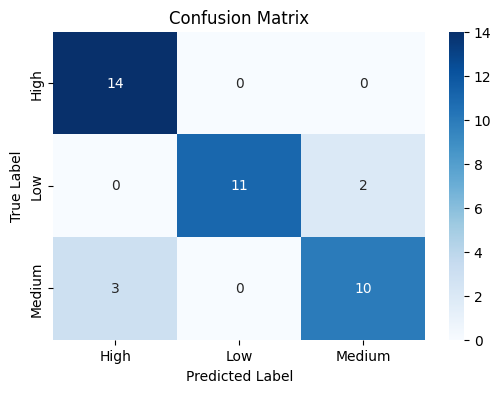

In [19]:
# ==================================================
# CONFUSION MATRIX
# ==================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


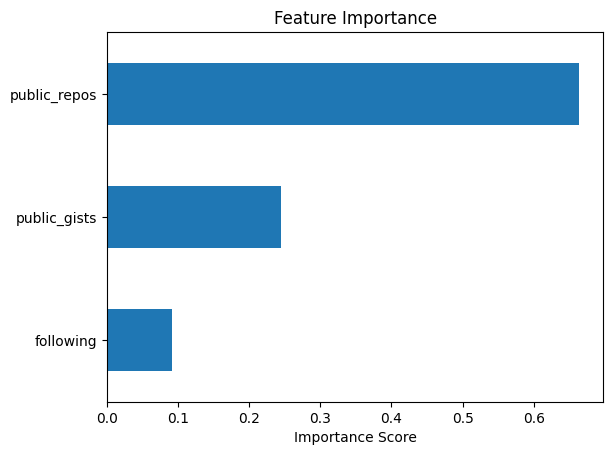

In [20]:
# ==================================================
# FEATURE IMPORTANCE
# ==================================================

import pandas as pd

importance = pd.Series(model.feature_importances_, index=features)

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()


In [25]:
# ==================================================
# DEMO PREDICTION
# ==================================================

new_candidate = pd.DataFrame({
    "public_repos": [110],
    "public_gists": [500],
    "following": [20]
})

prediction = model.predict(new_candidate)
probability = model.predict_proba(new_candidate)

print("Predicted Level:", prediction[0])
print("Class Probabilities:", probability)


Predicted Level: High
Class Probabilities: [[0.77 0.   0.23]]
